# Parte 3 &mdash; Abla&ccedil;&otilde;es

Duas abla&ccedil;&otilde;es sobre a **Trilha A** (Parte 2: fundo / interior / fronteira +
dist&acirc;ncia, decodificada por watershed). Cada configura&ccedil;&atilde;o roda com **2 seeds**
(42 e 43, controlando inicializa&ccedil;&atilde;o de pesos e embaralhamento &mdash; o split
treino/valida&ccedil;&atilde;o &eacute; sempre o mesmo, `SEED=42`, igual &agrave;s Partes 1 e 2), reportando
**m&eacute;dia &plusmn; desvio padr&atilde;o**.

## Eixo 1 &mdash; como recuperar resolu&ccedil;&atilde;o

A aula apresentou tr&ecirc;s mecanismos. Comparamos os **quatro** backbones que t&ecirc;m
prot&oacute;tipo em `src/nn/models.py`, cobrindo os tr&ecirc;s mecanismos (dois deles sob o
mesmo mecanismo &mdash; skip connections):

| Arquitetura | Mecanismo | Slides |
|---|---|---|
| `SegNet`    | pool indices (max unpooling) | 14, 16 |
| `UNet`      | skip connections | 25&ndash;29 |
| `ResUNet`   | skip connections + blocos residuais | 25&ndash;29 |
| `DeepLabV3` | atrous convolution mantendo o output stride + ASPP | 39&ndash;42 |

**Corre&ccedil;&otilde;es feitas em `src/nn/models.py`** antes desta abla&ccedil;&atilde;o (ver
`git log`/diff para o antes/depois):

* `SegNet` n&atilde;o fazia unpooling de verdade &mdash; usava `ConvTranspose2d` como a U-Net,
  ou seja, era uma U-Net sem skip connections, n&atilde;o o mecanismo de pool indices da
  aula. Reescrito com `nn.MaxPool2d(..., return_indices=True)` +
  `nn.MaxUnpool2d`.
* `SegNet` e `ResUNet` tinham larguras diferentes da U-Net (64/128/256 em vez de
  32/64/128) &mdash; a compara&ccedil;&atilde;o media capacidade, n&atilde;o mecanismo. `ResUNet` foi
  reescrita com a **mesma &aacute;rvore de concatena&ccedil;&otilde;es** da U-Net (192&rarr;64,
  96&rarr;32, 48&rarr;16); a &uacute;nica diferen&ccedil;a agora &eacute; `ConvBlock` &rarr; `ResidualBlock`.
* `DeepLabV3` tinha um backbone com DOIS pools (stride 2 + stride 2) e depois ASPP
  &mdash; ou seja, tamb&eacute;m perdia resolu&ccedil;&atilde;o como as outras e s&oacute; recuperava no fim.
  Reescrito para ter **um &uacute;nico pool**; a 3&ordf; camada do encoder usa convolu&ccedil;&atilde;o
  **dilatada** (`dilation=2`) na mesma resolu&ccedil;&atilde;o, no lugar do 2&ordm; pool &mdash; &eacute;
  literalmente "atrous convolution mantendo o output stride". S&oacute; precisa de UM
  upsample bilinear no final, n&atilde;o de tr&ecirc;s deconvolu&ccedil;&otilde;es aprendidas.

Todos os quatro expõem `forward_features(x)` (features na resolu&ccedil;&atilde;o original,
antes do classificador). O modelo da Trilha A vira gen&eacute;rico:

```python
backbone.forward_features(x)  ->  duas cabecas 1x1 (semantic, distance)
```

exatamente a mesma troca "s&oacute; o `final_conv` muda" da Parte 2, agora com o
backbone como vari&aacute;vel em vez das cabe&ccedil;as.

O **decodificador (loss) fica fixo** em `focal balanceada, gamma=2` &mdash; a
configura&ccedil;&atilde;o usada no `2_instances.ipynb` &mdash; para isolar a arquitetura como
&uacute;nica vari&aacute;vel.

## Eixo 2 &mdash; a fun&ccedil;&atilde;o de perda

CE &rarr; CE balanceada (peso &alpha;) &rarr; focal (&gamma;) &rarr; focal balanceada, variando
&gamma; &isin; {0, 1, 2, 5} nas duas &uacute;ltimas (slides 73&ndash;79). Mostra o efeito no
desbalanceamento da Parte 2, que &eacute; severo: a classe fronteira &eacute; uma fra&ccedil;&atilde;o
min&uacute;scula da imagem (a c&eacute;lula de diagn&oacute;stico do `2_instances.ipynb` mede isso
diretamente). Al&eacute;m das m&eacute;tricas de inst&acirc;ncia, reportamos o **recall da classe
fronteira**, que &eacute; a evid&ecirc;ncia direta do balanceamento (n&atilde;o a acur&aacute;cia global,
que o fundo infla). O **backbone fica fixo** em `UNet` (o da Parte 1/2).

`balanced_cross_entropy` e `focal_loss` (implementadas em `src/nn/loss.py`) j&aacute;
existiam como esbo&ccedil;o e foram completadas nesta entrega.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

from PIL import Image
import torchvision.transforms.functional as TF

from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform

from src.nn.models import SegNet, UNet, ResUNet, DeepLabV3
from src.nn.optimizers import create_optimizer

from src.nn.loss import cross_entropy, balanced_cross_entropy, focal_loss, l1_loss

from src.nn.targets import instance_map_to_boundary_targets, decode_watershed

from src.nn.metrics import (
    binary_iou_dice,
    instance_scores,
    count_tp_fp_fn,
    mean_average_precision,
)

In [2]:
# ============================================================
# CONFIGURACOES
# ============================================================

SPLIT_SEED = 42          # split treino/validacao -- IGUAL as Partes 1 e 2
SEEDS      = [42, 43]    # 2 seeds por configuracao (pesos + embaralhamento)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE      = (128, 128)
BOUNDARY_WIDTH  = 2
MIN_INST_PIXELS = 4

INTERIOR_THRESH = 0.50
MIN_MARKER_SIZE = 5
DISTANCE_WEIGHT = 1.0

# Config "vencedora" da Parte 2 -- fica FIXA no Eixo 1 (so a arquitetura varia)
DEFAULT_LOSS = dict(kind="focal", gamma=2.0, balanced=True)
# Backbone fixo no Eixo 2 (o da Parte 1/2)
DEFAULT_BACKBONE = "unet"

batch_size = 16

# --------------------------------------------------------------
# Orcamento de epocas da ablacao. NAO e o numero final de epocas
# da apresentacao (Parte 2 usou 15) -- e um orcamento menor para
# caber 28 treinos (8 do Eixo 1 + 20 do Eixo 2) num notebook.
# Meça o tempo real de 1 epoca abaixo antes de decidir se aumenta.
# --------------------------------------------------------------
EPOCHS_ABLATION = 6

# Limite opcional de imagens de validacao por avaliacao (None = todas
# as 134). Reduzir acelera a exploracao; para os numeros finais, use None.
EVAL_MAX_IMAGES = None

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = ["fundo", "interior", "fronteira"]

Device: cpu


## Backbones, alvos e avalia&ccedil;&atilde;o (compartilhados pelos dois eixos)

In [3]:
# ============================================================
# BACKBONES  --  mesmo esquema de larguras (32/64/128), so o
# mecanismo de recuperacao de resolucao muda (ver src/nn/models.py)
# ============================================================

BACKBONES = {
    "segnet":  SegNet,
    "unet":    UNet,
    "resunet": ResUNet,
    "deeplab": DeepLabV3,
}

FEATURE_CHANNELS = {
    "segnet": 32, "unet": 16, "resunet": 16, "deeplab": 64,
}

# output stride = fator de reducao de resolucao antes do "gargalo".
# UNet/SegNet/ResUNet fazem 3 max-pools (2^3 = 8); DeepLab troca o
# 2o pool por convolucao dilatada e faz so 1 (2^1 = 2).
OUTPUT_STRIDE = {
    "segnet": 8, "unet": 8, "resunet": 8, "deeplab": 2,
}

BACKBONE_LABELS = {
    "segnet": "SegNet (pool indices)",
    "unet": "U-Net (skip connections)",
    "resunet": "ResUNet (skip + residual)",
    "deeplab": "DeepLabV3 (atrous + ASPP)",
}


class TrilhaAModel(nn.Module):
    """
    Duas cabecas (semantic 3 classes, distance 1 canal) sobre QUALQUER
    um dos backbones acima. E a mesma troca da Parte 2 -- so o
    `final_conv` de 1x1 muda -- agora com o backbone inteiro como a
    variavel do experimento, nao as cabecas.
    """

    def __init__(self, backbone_kind):
        super().__init__()

        self.backbone_kind = backbone_kind
        self.backbone = BACKBONES[backbone_kind](num_classes=2)  # num_classes p/ compat; nao usado

        c = FEATURE_CHANNELS[backbone_kind]
        self.semantic_head = nn.Conv2d(c, 3, kernel_size=1)
        self.distance_head = nn.Conv2d(c, 1, kernel_size=1)

    def forward(self, x):
        feat = self.backbone.forward_features(x)
        return self.semantic_head(feat), self.distance_head(feat)

In [4]:
# ============================================================
# ALVOS  +  PERDAS (Eixo 2)  +  HELPERS DE DECODIFICACAO
# ============================================================

def build_targets(instance_map_batch):
    sem, dist = [], []
    for i in range(instance_map_batch.shape[0]):
        s, d = instance_map_to_boundary_targets(
            instance_map_batch[i].detach().cpu().numpy(),
            boundary_width=BOUNDARY_WIDTH,
            min_pixels=MIN_INST_PIXELS,
        )
        sem.append(s)
        dist.append(d)
    return torch.stack(sem), torch.stack(dist)


def make_semantic_loss(loss_cfg):
    """
    loss_cfg (Eixo 2): CE -> CE balanceada -> focal -> focal balanceada.

        {"kind": "ce"}
        {"kind": "balanced_ce"}
        {"kind": "focal", "gamma": G, "balanced": False}
        {"kind": "focal", "gamma": G, "balanced": True}
    """
    kind = loss_cfg["kind"]

    if kind == "ce":
        return lambda pred, target: cross_entropy(pred, target)

    if kind == "balanced_ce":
        return lambda pred, target: balanced_cross_entropy(pred, target)

    if kind == "focal":
        gamma = loss_cfg["gamma"]
        class_weights = "balanced" if loss_cfg["balanced"] else None
        return lambda pred, target: focal_loss(pred, target, class_weights=class_weights, gamma=gamma)

    raise ValueError(f"loss_cfg desconhecido: {loss_cfg}")


def masks_to_list(instance_map):
    ids = np.unique(instance_map)
    ids = ids[ids > 0]
    return [instance_map == i for i in ids]


def resize_gt(gt_bool, size):
    img = Image.fromarray((gt_bool.astype(np.uint8) * 255))
    img = TF.resize(img, size, interpolation=TF.InterpolationMode.NEAREST)
    return np.array(img) > 0


def semantic_from_outputs(sem_prob):
    fg_prob = sem_prob[1] + sem_prob[2]
    fg_mask = sem_prob.argmax(axis=0) != 0
    return fg_prob, fg_mask


def watershed_from_outputs(sem_prob, dist_pred):
    interior_mask   = sem_prob[1] > INTERIOR_THRESH
    foreground_mask = sem_prob.argmax(axis=0) != 0
    return decode_watershed(
        interior_mask=interior_mask,
        foreground_mask=foreground_mask,
        landscape=-dist_pred,
        min_marker_size=MIN_MARKER_SIZE,
    )

In [5]:
# ============================================================
# TREINO  +  AVALIACAO  (uma chamada = um (config, seed) treinado do zero)
# ============================================================

def train_epoch(dataloader, model, optimizer, device, semantic_loss_fn):

    model.train()
    acc = {"loss": 0.0, "semantic": 0.0, "distance": 0.0}

    for X, instance_map in dataloader:

        X = X.to(device)
        sem_t, dist_t = build_targets(instance_map)
        sem_t, dist_t = sem_t.to(device), dist_t.to(device)

        sem_logits, dist_logits = model(X)
        dist_pred = torch.sigmoid(dist_logits).squeeze(1)

        sem_loss  = semantic_loss_fn(sem_logits, sem_t)
        dist_loss = l1_loss(dist_pred, dist_t)

        loss = sem_loss + DISTANCE_WEIGHT * dist_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        acc["loss"]     += loss.item()
        acc["semantic"] += sem_loss.item()
        acc["distance"] += dist_loss.item()

    n = len(dataloader)
    return {k: v / n for k, v in acc.items()}


@torch.no_grad()
def evaluate_model(model, dataloader, base_dataset, device, max_images=None):
    """
    Decodifica por watershed (a propria Trilha A, sem comparar de novo
    com a baseline de componentes conexos -- isso ja foi feito na
    Parte 2) e devolve metricas semanticas + de instancia + recall por
    classe (evidencia direta do balanceamento no Eixo 2).
    """
    model.eval()
    subset_indices = dataloader.dataset.indices
    pos = 0

    predictions, ground_truths, scores, count_err = [], [], [], []
    sem_iou, sem_dice = [], []
    class_tp = np.zeros(3); class_fn = np.zeros(3); class_fp = np.zeros(3)

    for X, instance_map in dataloader:

        X = X.to(device)
        sem_logits, dist_logits = model(X)
        sem_prob  = torch.softmax(sem_logits, dim=1).cpu().numpy()
        dist_pred = torch.sigmoid(dist_logits).squeeze(1).cpu().numpy()

        sem_gt_batch, _ = build_targets(instance_map)
        sem_gt_batch = sem_gt_batch.numpy()
        pred_cls_batch = sem_prob.argmax(axis=1)

        for i in range(X.shape[0]):

            if max_images is not None and pos >= max_images:
                break

            fg_prob, fg_mask = semantic_from_outputs(sem_prob[i])
            size = fg_mask.shape

            sample = base_dataset.samples[int(subset_indices[pos])]
            pos += 1
            gt = [resize_gt(g, size) for g in base_dataset._load_instance_masks(sample["masks"])]
            gt_union = np.zeros(size, dtype=bool)
            for g in gt:
                gt_union |= g
            ground_truths.append(gt)

            iou, dice = binary_iou_dice(fg_mask, gt_union)
            sem_iou.append(iou); sem_dice.append(dice)

            for c in range(3):
                pc, gc_ = pred_cls_batch[i] == c, sem_gt_batch[i] == c
                class_tp[c] += np.sum(pc & gc_)
                class_fn[c] += np.sum(~pc & gc_)
                class_fp[c] += np.sum(pc & ~gc_)

            lab = watershed_from_outputs(sem_prob[i], dist_pred[i])
            inst = masks_to_list(lab)

            predictions.append(inst)
            scores.append(instance_scores(fg_prob, inst))
            count_err.append(abs(len(inst) - len(gt)))

        if max_images is not None and pos >= max_images:
            break

    thresholds = np.arange(0.50, 0.951, 0.05)
    map_value, _ = mean_average_precision(predictions, ground_truths, scores, thresholds=thresholds)
    tp50, fp50, fn50 = count_tp_fp_fn(predictions, ground_truths, 0.50)

    recall = class_tp / (class_tp + class_fn + 1e-9)

    return {
        "iou": float(np.mean(sem_iou)),
        "dice": float(np.mean(sem_dice)),
        "map": float(map_value),
        "count_error": float(np.mean(count_err)),
        "tp50": int(tp50), "fp50": int(fp50), "fn50": int(fn50),
        "recall_fundo": float(recall[0]),
        "recall_interior": float(recall[1]),
        "recall_fronteira": float(recall[2]),
    }


def run_config(backbone_kind, loss_cfg, seed, train_loader, eval_loader,
              eval_dataset, epochs, verbose=True):
    """Treina UM modelo do zero (uma seed) e devolve suas metricas finais."""

    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    model = TrilhaAModel(backbone_kind).to(device)
    optimizer = create_optimizer("Adam", model, lr=1e-3)
    semantic_loss_fn = make_semantic_loss(loss_cfg)

    t0 = time.time()
    for epoch in range(epochs):
        logs = train_epoch(train_loader, model, optimizer, device, semantic_loss_fn)
    train_time = time.time() - t0

    metrics = evaluate_model(model, eval_loader, eval_dataset, device, max_images=EVAL_MAX_IMAGES)
    metrics["train_seconds"] = train_time
    metrics["final_loss"] = logs["loss"]

    if verbose:
        print(
            f"    seed {seed} | loss {logs['loss']:.4f} | "
            f"IoU {metrics['iou']:.3f} | mAP {metrics['map']:.3f} | "
            f"erro contagem {metrics['count_error']:.2f} | {train_time:.1f}s"
        )

    return metrics

In [6]:
# ============================================================
# DADOS  --  MESMO SPLIT DAS PARTES 1 E 2
# ============================================================

train_transform = SegmentationTransform(size=IMAGE_SIZE, augment=True)
eval_transform  = SegmentationTransform(size=IMAGE_SIZE, augment=False)

train_dataset_full = BBBC038Dataset(root="../data/stage1_train", transform=train_transform, mode="instance")
eval_dataset_full  = BBBC038Dataset(root="../data/stage1_train", transform=eval_transform,  mode="instance")

n_total = len(train_dataset_full)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

train_split, _ = random_split(train_dataset_full, [n_train, n_val], generator=torch.Generator().manual_seed(SPLIT_SEED))
_, val_split   = random_split(eval_dataset_full,  [n_train, n_val], generator=torch.Generator().manual_seed(SPLIT_SEED))

print(f"treino: {len(train_split)}  |  validacao: {len(val_split)}")

train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True,  num_workers=0)
eval_loader  = DataLoader(val_split,   batch_size=batch_size, shuffle=False, num_workers=0)

treino: 536  |  validacao: 134


## Or&ccedil;amento de tempo

Medido, n&atilde;o chutado: uma &eacute;poca de treino inteira (536 imagens) e uma avalia&ccedil;&atilde;o
completa (watershed + m&eacute;tricas de inst&acirc;ncia nas imagens de valida&ccedil;&atilde;o), com o
backbone padr&atilde;o, **antes** de disparar os 28 treinos. Achado emp&iacute;rico: o treino
domina o custo (~70s/&eacute;poca em CPU); a avalia&ccedil;&atilde;o &eacute; barata mesmo no conjunto de
valida&ccedil;&atilde;o inteiro (~0,15&ndash;0,3 s/imagem) &mdash; por isso `EVAL_MAX_IMAGES=None` (as
134 imagens) fica como padr&atilde;o, sem custar o gargalo do notebook.

In [7]:
_probe_model = TrilhaAModel(DEFAULT_BACKBONE).to(device)
_probe_opt = create_optimizer("Adam", _probe_model, lr=1e-3)
_probe_loss = make_semantic_loss(DEFAULT_LOSS)

t0 = time.time()
train_epoch(train_loader, _probe_model, _probe_opt, device, _probe_loss)
epoch_seconds = time.time() - t0

t0 = time.time()
evaluate_model(_probe_model, eval_loader, eval_dataset_full, device, max_images=EVAL_MAX_IMAGES)
eval_seconds = time.time() - t0

n_runs = len(BACKBONES) * len(SEEDS) + 10 * len(SEEDS)   # Eixo 1 + Eixo 2
seconds_per_run = epoch_seconds * EPOCHS_ABLATION + eval_seconds
est_total_hours = seconds_per_run * n_runs / 3600

print(f"1 epoca de treino (backbone={DEFAULT_BACKBONE}, 536 imagens): {epoch_seconds:.1f}s")
print(f"1 avaliacao completa ({'todas as' if EVAL_MAX_IMAGES is None else EVAL_MAX_IMAGES} imagens de validacao): {eval_seconds:.1f}s")
print(f"\norcamento: {EPOCHS_ABLATION} epocas + 1 eval, x {n_runs} treinos "
      f"(4 backbones + 10 configs de perda, x{len(SEEDS)} seeds)")
print(f"~{seconds_per_run/60:.1f} min por treino  ->  ~{est_total_hours:.1f} h no total")
print("\nSe o total for alto demais: baixe EPOCHS_ABLATION, rode so um subconjunto")
print("dos LOSS_CONFIGS (Eixo 2), ou troque para GPU. EVAL_MAX_IMAGES ja e barato,")
print("nao precisa reduzir.")

del _probe_model, _probe_opt

1 epoca de treino (backbone=unet, 536 imagens): 75.1s
1 avaliacao completa (todas as imagens de validacao): 87.4s

orcamento: 6 epocas + 1 eval, x 28 treinos (4 backbones + 10 configs de perda, x2 seeds)
~9.0 min por treino  ->  ~4.2 h no total

Se o total for alto demais: baixe EPOCHS_ABLATION, rode so um subconjunto
dos LOSS_CONFIGS (Eixo 2), ou troque para GPU. EVAL_MAX_IMAGES ja e barato,
nao precisa reduzir.


## Eixo 1 &mdash; como recuperar resolu&ccedil;&atilde;o

Perda fixa: `focal balanceada, gamma=2` (a mesma do `2_instances.ipynb`).

In [8]:
axis1_rows = []

for backbone_kind in BACKBONES:
    print(f"\n=== Eixo 1 | {BACKBONE_LABELS[backbone_kind]} ===")

    for seed in SEEDS:
        metrics = run_config(
            backbone_kind, DEFAULT_LOSS, seed,
            train_loader, eval_loader, eval_dataset_full,
            epochs=EPOCHS_ABLATION,
        )
        metrics["backbone"] = backbone_kind
        metrics["seed"] = seed
        axis1_rows.append(metrics)

        with open(os.path.join(RESULTS_DIR, "3_ablations_axis1_partial.json"), "w") as fh:
            json.dump(axis1_rows, fh, indent=2)

axis1_df = pd.DataFrame(axis1_rows)
axis1_df.to_csv(os.path.join(RESULTS_DIR, "3_ablations_axis1.csv"), index=False)
axis1_df


=== Eixo 1 | SegNet (pool indices) ===
    seed 42 | loss 0.1791 | IoU 0.670 | mAP 0.081 | erro contagem 32.23 | 426.7s
    seed 43 | loss 0.2141 | IoU 0.661 | mAP 0.101 | erro contagem 29.37 | 466.9s

=== Eixo 1 | U-Net (skip connections) ===
    seed 42 | loss 0.2701 | IoU 0.581 | mAP 0.060 | erro contagem 33.57 | 496.2s
    seed 43 | loss 0.2976 | IoU 0.694 | mAP 0.107 | erro contagem 29.44 | 541.1s

=== Eixo 1 | ResUNet (skip + residual) ===
    seed 42 | loss 0.1522 | IoU 0.686 | mAP 0.099 | erro contagem 29.66 | 766.8s
    seed 43 | loss 0.1490 | IoU 0.693 | mAP 0.128 | erro contagem 27.36 | 573.8s

=== Eixo 1 | DeepLabV3 (atrous + ASPP) ===
    seed 42 | loss 0.1582 | IoU 0.725 | mAP 0.104 | erro contagem 33.96 | 1083.7s
    seed 43 | loss 0.1577 | IoU 0.665 | mAP 0.098 | erro contagem 29.51 | 1044.2s


,iou,dice,map,count_error,tp50,fp50,fn50,recall_fundo,recall_interior,recall_fronteira,train_seconds,final_loss,backbone,seed
0,0.669796,0.790942,0.080668,32.231343,1562,761,5078,0.929451,0.843702,0.798562,426.706020,0.179116,segnet,42
1,0.660998,0.783844,0.100665,29.365672,1867,860,4773,0.937084,0.805097,0.778856,466.902872,0.214088,segnet,43
2,0.581255,0.717506,0.060254,33.574627,1456,699,5184,0.899947,0.805518,0.866075,496.183220,0.270092,unet,42
3,0.693666,0.810174,0.106810,29.440299,1935,762,4705,0.939332,0.816916,0.816993,541.083704,0.297567,unet,43
4,0.685904,0.804232,0.099416,29.656716,1850,822,4790,0.932901,0.856085,0.785958,766.843534,0.152185,resunet,42
5,0.692922,0.807686,0.127911,27.358209,2142,840,4498,0.936291,0.849149,0.800382,573.793200,0.149004,resunet,43
6,0.724954,0.831942,0.103713,33.955224,1591,513,5049,0.944874,0.809838,0.834034,1083.711652,0.158207,deeplab,42
7,0.665112,0.786289,0.097713,29.507463,1968,786,4672,0.929550,0.719938,0.872112,1044.166694,0.157663,deeplab,43


In [9]:
# ============================================================
# EIXO 1  --  MEDIA +- DESVIO PADRAO POR ARQUITETURA
# ============================================================

metric_cols = ["iou", "dice", "map", "count_error"]

axis1_summary = (
    axis1_df
    .groupby("backbone")[metric_cols]
    .agg(["mean", "std"])
)

# metadados: parametros e output stride de cada backbone
param_counts = {
    k: sum(p.numel() for p in TrilhaAModel(k).parameters())
    for k in BACKBONES
}

axis1_summary.insert(0, "output_stride", [OUTPUT_STRIDE[b] for b in axis1_summary.index])
axis1_summary.insert(1, "params", [param_counts[b] for b in axis1_summary.index])
axis1_summary.index = [BACKBONE_LABELS[b] for b in axis1_summary.index]

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
axis1_summary

output_stride  params    iou          dice         \
                                                  mean    std   mean    std   
DeepLabV3 (atrous + ASPP)             2  535014 0.6950 0.0423 0.8091 0.0323   
ResUNet (skip + residual)             8  552134 0.6894 0.0050 0.8060 0.0024   
SegNet (pool indices)                 8  445542 0.6654 0.0062 0.7874 0.0050   
U-Net (skip connections)              8  525334 0.6375 0.0795 0.7638 0.0655   

                             map        count_error         
                            mean    std        mean    std  
DeepLabV3 (atrous + ASPP) 0.1007 0.0042     31.7313 3.1450  
ResUNet (skip + residual) 0.1137 0.0201     28.5075 1.6253  
SegNet (pool indices)     0.0907 0.0141     30.7985 2.0263  
U-Net (skip connections)  0.0835 0.0329     31.5075 2.9234

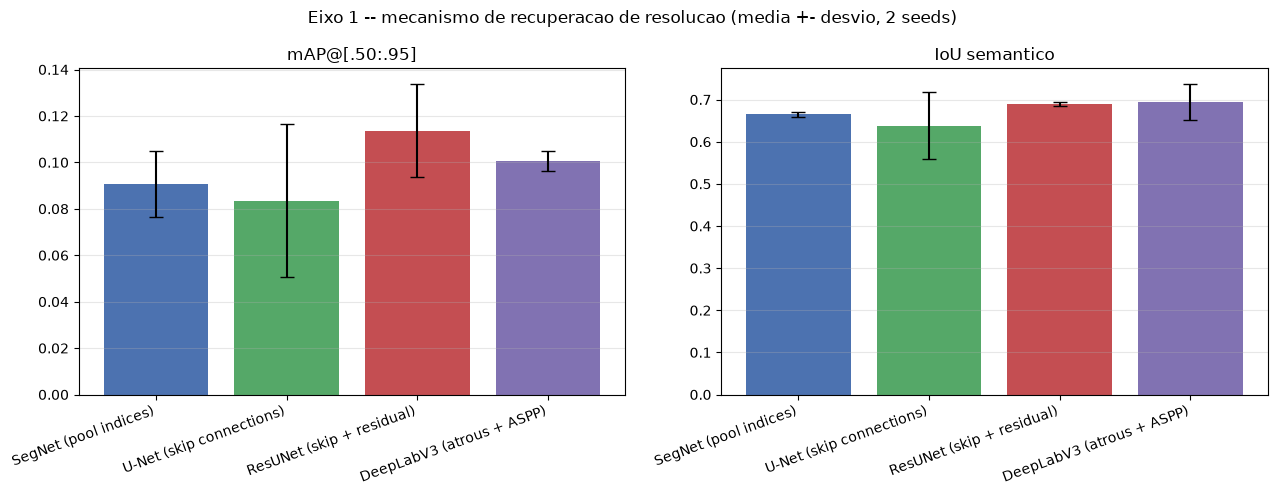

In [10]:
# ============================================================
# EIXO 1  --  GRAFICO (mAP e IoU, com barra de erro = desvio padrao)
# ============================================================

labels = [BACKBONE_LABELS[b] for b in BACKBONES]
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [(axes[0], "map", "mAP@[.50:.95]"), (axes[1], "iou", "IoU semantico")]:
    means = [axis1_df[axis1_df.backbone == b][metric].mean() for b in BACKBONES]
    stds  = [axis1_df[axis1_df.backbone == b][metric].std()  for b in BACKBONES]
    ax.bar(x, means, yerr=stds, capsize=5, color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"])
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Eixo 1 -- mecanismo de recuperacao de resolucao (media +- desvio, 2 seeds)")
plt.tight_layout(); plt.show()

## Eixo 2 &mdash; a fun&ccedil;&atilde;o de perda

Backbone fixo: `UNet`. Dez configura&ccedil;&otilde;es: CE, CE balanceada, e o cruzamento
focal &times; focal-balanceada &times; &gamma; &isin; {0,1,2,5} (&gamma;=0 &eacute; a &acirc;ncora de
sanidade: focal com &gamma;=0 tem que coincidir com CE / CE balanceada).

In [11]:
LOSS_CONFIGS = {
    "CE":                       dict(kind="ce"),
    "CE balanceada":            dict(kind="balanced_ce"),
    "Focal gamma=0":            dict(kind="focal", gamma=0.0, balanced=False),
    "Focal gamma=1":            dict(kind="focal", gamma=1.0, balanced=False),
    "Focal gamma=2":            dict(kind="focal", gamma=2.0, balanced=False),
    "Focal gamma=5":            dict(kind="focal", gamma=5.0, balanced=False),
    "Focal balanceada gamma=0": dict(kind="focal", gamma=0.0, balanced=True),
    "Focal balanceada gamma=1": dict(kind="focal", gamma=1.0, balanced=True),
    "Focal balanceada gamma=2": dict(kind="focal", gamma=2.0, balanced=True),
    "Focal balanceada gamma=5": dict(kind="focal", gamma=5.0, balanced=True),
}

axis2_rows = []

for name, loss_cfg in LOSS_CONFIGS.items():
    print(f"\n=== Eixo 2 | {name} ===")

    for seed in SEEDS:
        metrics = run_config(
            DEFAULT_BACKBONE, loss_cfg, seed,
            train_loader, eval_loader, eval_dataset_full,
            epochs=EPOCHS_ABLATION,
        )
        metrics["loss_config"] = name
        metrics["gamma"] = loss_cfg.get("gamma", np.nan)
        metrics["balanced"] = loss_cfg.get("balanced", name == "CE balanceada")
        metrics["seed"] = seed
        axis2_rows.append(metrics)

        with open(os.path.join(RESULTS_DIR, "3_ablations_axis2_partial.json"), "w") as fh:
            json.dump(axis2_rows, fh, indent=2)

axis2_df = pd.DataFrame(axis2_rows)
axis2_df.to_csv(os.path.join(RESULTS_DIR, "3_ablations_axis2.csv"), index=False)
axis2_df


=== Eixo 2 | CE ===
    seed 42 | loss 0.3533 | IoU 0.550 | mAP 0.000 | erro contagem 49.55 | 592.3s
    seed 43 | loss 0.3718 | IoU 0.751 | mAP 0.136 | erro contagem 34.82 | 550.2s

=== Eixo 2 | CE balanceada ===
    seed 42 | loss 0.5468 | IoU 0.486 | mAP 0.078 | erro contagem 30.22 | 459.6s
    seed 43 | loss 0.5935 | IoU 0.667 | mAP 0.115 | erro contagem 27.78 | 456.5s

=== Eixo 2 | Focal gamma=0 ===
    seed 42 | loss 0.3533 | IoU 0.550 | mAP 0.000 | erro contagem 49.55 | 380.1s
    seed 43 | loss 0.3718 | IoU 0.751 | mAP 0.136 | erro contagem 34.82 | 385.3s

=== Eixo 2 | Focal gamma=1 ===
    seed 42 | loss 0.2523 | IoU 0.498 | mAP 0.000 | erro contagem 49.55 | 392.7s
    seed 43 | loss 0.2727 | IoU 0.745 | mAP 0.108 | erro contagem 38.03 | 384.1s

=== Eixo 2 | Focal gamma=2 ===
    seed 42 | loss 0.2005 | IoU 0.559 | mAP 0.000 | erro contagem 49.55 | 386.2s
    seed 43 | loss 0.2301 | IoU 0.734 | mAP 0.088 | erro contagem 39.79 | 386.0s

=== Eixo 2 | Focal gamma=5 ===
    seed 

,iou,dice,map,count_error,tp50,fp50,fn50,recall_fundo,recall_interior,recall_fronteira,train_seconds,final_loss,loss_config,gamma,balanced,seed
0,0.5498,0.6844,0.0000,49.5522,0,0,6640,0.9819,0.0000,0.7222,592.3024,0.3533,CE,NaN,False,42
1,0.7506,0.8448,0.1358,34.8209,1599,403,5041,0.9835,0.6539,0.6933,550.2395,0.3718,CE,NaN,False,43
2,0.4865,0.6199,0.0776,30.2239,1740,1550,4900,0.7748,0.8013,0.8615,459.6392,0.5468,CE balanceada,NaN,True,42
3,0.6670,0.7909,0.1148,27.7836,2126,795,4514,0.9367,0.7562,0.8551,456.4566,0.5935,CE balanceada,NaN,True,43
4,0.5498,0.6844,0.0000,49.5522,0,0,6640,0.9819,0.0000,0.7222,380.0965,0.3533,Focal gamma=0,0.0000,False,42
5,0.7506,0.8448,0.1358,34.8209,1599,403,5041,0.9835,0.6539,0.6933,385.3417,0.3718,Focal gamma=0,0.0000,False,43
6,0.4976,0.6368,0.0000,49.5522,0,0,6640,0.9877,0.3150,0.5835,392.6983,0.2523,Focal gamma=1,1.0000,False,42
7,0.7448,0.8394,0.1080,38.0299,1262,284,5378,0.9876,0.6809,0.6442,384.1467,0.2727,Focal gamma=1,1.0000,False,43
8,0.5593,0.7049,0.0000,49.5522,0,0,6640,0.9708,0.5809,0.6714,386.1723,0.2005,Focal gamma=2,2.0000,False,42
9,0.7342,0.8342,0.0880,39.7910,1113,195,5527,0.9877,0.6353,0.6343,386.0385,0.2301,Focal gamma=2,2.0000,False,43


In [12]:
# ============================================================
# EIXO 2  --  MEDIA +- DESVIO PADRAO POR CONFIGURACAO DE PERDA
# ============================================================

metric_cols2 = ["iou", "map", "count_error", "recall_fronteira", "recall_interior"]

axis2_summary = (
    axis2_df
    .groupby("loss_config")[metric_cols2]
    .agg(["mean", "std"])
    .reindex(list(LOSS_CONFIGS.keys()))
)

axis2_summary

iou           map        count_error          \
                           mean    std   mean    std        mean     std   
loss_config                                                                
CE                       0.6502 0.1420 0.0679 0.0960     42.1866 10.4166   
CE balanceada            0.5767 0.1277 0.0962 0.0263     29.0037  1.7256   
Focal gamma=0            0.6502 0.1420 0.0679 0.0960     42.1866 10.4166   
Focal gamma=1            0.6212 0.1748 0.0540 0.0764     43.7910  8.1476   
Focal gamma=2            0.6468 0.1237 0.0440 0.0623     44.6716  6.9022   
Focal gamma=5            0.7005 0.0231 0.0527 0.0100     41.7276  3.8785   
Focal balanceada gamma=0 0.6335 0.0092 0.0928 0.0026     27.6381  1.7467   
Focal balanceada gamma=1 0.5728 0.1643 0.1032 0.0444     27.4627  0.3377   
Focal balanceada gamma=2 0.6375 0.0795 0.0835 0.0329     31.5075  2.9234   
Focal balanceada gamma=5 0.5954 0.0750 0.0521 0.0219     37.2575  4.0263   

                         recall_fronteira        recall_interior         
                                     mean    std            mean    std  
loss_config                                                              
CE                                 0.7078 0.0205          0.3269 0.4624  
CE balanceada                      0.8583 0.0045          0.7788 0.0319  
Focal gamma=0                      0.7078 0.0205          0.3269 0.4624  
Focal gamma=1                      0.6138 0.0429          0.4979 0.2587  
Focal gamma=2                      0.6528 0.0262          0.6081 0.0384  
Focal gamma=5                      0.5898 0.0307          0.5547 0.1293  
Focal balanceada gamma=0           0.8457 0.0404          0.7857 0.0058  
Focal balanceada gamma=1           0.8170 0.0078          0.8212 0.0475  
Focal balanceada gamma=2           0.8415 0.0347          0.8112 0.0081  
Focal balanceada gamma=5           0.8541 0.0662          0.6907 0.0229

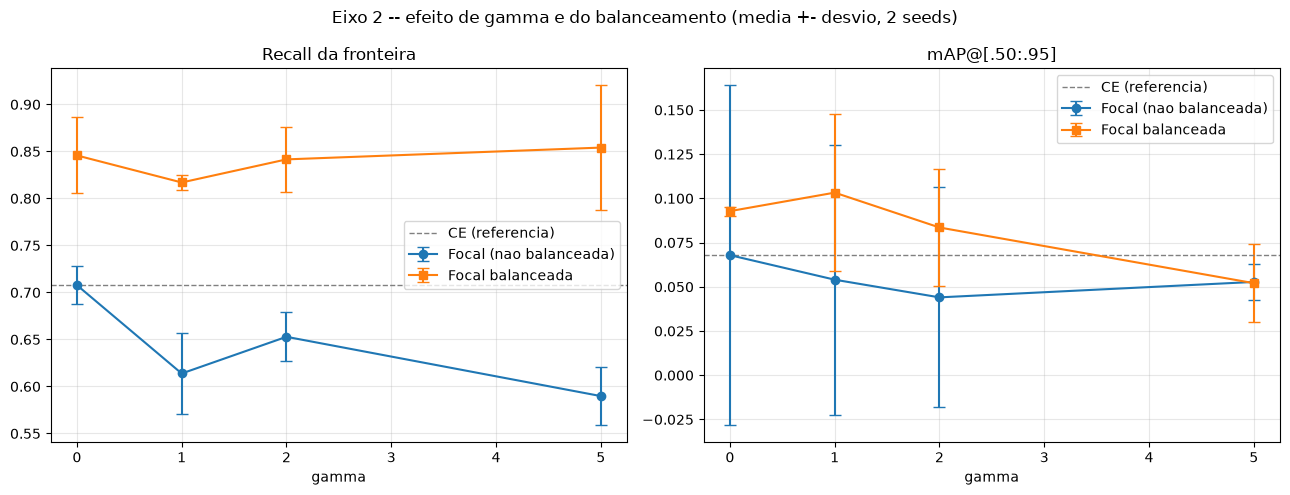

In [13]:
# ============================================================
# EIXO 2  --  RECALL DA FRONTEIRA  x  GAMMA
# ============================================================
#
# A evidencia direta do desbalanceamento: recall da classe minoritaria
# (fronteira) conforme gamma cresce, focal comum vs. focal balanceada.
# ============================================================

gammas = [0, 1, 2, 5]

def _series(prefix, metric):
    means, stds = [], []
    for g in gammas:
        rows = axis2_df[axis2_df.loss_config == f"{prefix} gamma={g}"]
        means.append(rows[metric].mean())
        stds.append(rows[metric].std())
    return np.array(means), np.array(stds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [(axes[0], "recall_fronteira", "Recall da fronteira"),
                          (axes[1], "map", "mAP@[.50:.95]")]:
    m1, s1 = _series("Focal", metric)
    m2, s2 = _series("Focal balanceada", metric)
    ax.errorbar(gammas, m1, yerr=s1, marker="o", capsize=4, label="Focal (nao balanceada)")
    ax.errorbar(gammas, m2, yerr=s2, marker="s", capsize=4, label="Focal balanceada")
    ax.axhline(axis2_df[axis2_df.loss_config == "CE"][metric].mean(),
              color="gray", linestyle="--", linewidth=1, label="CE (referencia)")
    ax.set_xlabel("gamma"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Eixo 2 -- efeito de gamma e do balanceamento (media +- desvio, 2 seeds)")
plt.tight_layout(); plt.show()

In [14]:
# ============================================================
# SALVA OS NUMEROS DA PARTE 3
# ============================================================

payload = {
    "eixo1": {
        b: {
            "output_stride": OUTPUT_STRIDE[b],
            "params": param_counts[b],
            **{
                f"{m}_{stat}": float(axis1_df[axis1_df.backbone == b][m].agg(stat))
                for m in metric_cols for stat in ("mean", "std")
            },
        }
        for b in BACKBONES
    },
    "eixo2": {
        name: {
            f"{m}_{stat}": float(axis2_df[axis2_df.loss_config == name][m].agg(stat))
            for m in metric_cols2 for stat in ("mean", "std")
        }
        for name in LOSS_CONFIGS
    },
    "config": {
        "epochs_ablation": EPOCHS_ABLATION,
        "seeds": SEEDS,
        "default_loss_eixo1": DEFAULT_LOSS,
        "default_backbone_eixo2": DEFAULT_BACKBONE,
    },
}

with open(os.path.join(RESULTS_DIR, "3_ablations.json"), "w") as fh:
    json.dump(payload, fh, indent=2)

print(json.dumps(payload, indent=2))

{
  "eixo1": {
    "segnet": {
      "output_stride": 8,
      "params": 445542,
      "iou_mean": 0.6653969541518316,
      "iou_std": 0.006220957737003455,
      "dice_mean": 0.787392936100788,
      "dice_std": 0.005018692677275285,
      "map_mean": 0.09066632930655963,
      "map_std": 0.014140130001455932,
      "count_error_mean": 30.79850746268657,
      "count_error_std": 2.0263358505644358
    },
    "unet": {
      "output_stride": 8,
      "params": 525334,
      "iou_mean": 0.6374606564153024,
      "iou_std": 0.07948690783924778,
      "dice_mean": 0.7638403584914304,
      "dice_std": 0.06552632805468948,
      "map_mean": 0.08353239862393574,
      "map_std": 0.03292000904173645,
      "count_error_mean": 31.507462686567163,
      "count_error_std": 2.923411617741397
    },
    "resunet": {
      "output_stride": 8,
      "params": 552134,
      "iou_mean": 0.6894130304166878,
      "iou_std": 0.0049624972993929034,
      "dice_mean": 0.8059592555437045,
      "dice_std

**Eixo 1.** SegNet (pool indices) n&atilde;o tem como recuperar informa&ccedil;&atilde;o que o
max-pooling descartou &mdash; s&oacute; sabe ONDE cada m&aacute;ximo estava, n&atilde;o o que havia ao
redor. U-Net/ResUNet (skip connections) devolvem as features inteiras do
encoder, sem perda de informa&ccedil;&atilde;o de textura fina. DeepLabV3 (atrous) nem
perde essa informa&ccedil;&atilde;o para come&ccedil;ar &mdash; o output stride 2 (contra 8 das outras
tr&ecirc;s) significa 4&times; mais resolu&ccedil;&atilde;o chegando na ASPP. Qual desses efeitos pesa
mais em mAP/erro de contagem &eacute; exatamente o que o gr&aacute;fico acima mostra.

**Eixo 2.** Com `gamma=0`, focal e focal-balanceada colapsam em CE e CE
balanceada (confira nos n&uacute;meros). Conforme `gamma` cresce, o recall da
fronteira deve subir na vers&atilde;o balanceada e a curva `mAP x gamma` mostra se
existe um ponto de satura&ccedil;&atilde;o (ou piora, se `gamma` focar demais em ru&iacute;do de
r&oacute;tulo). Isso valida (ou corrige) a escolha `gamma=2` feita de largada no
`2_instances.ipynb`.

**Limita&ccedil;&otilde;es desta abla&ccedil;&atilde;o:** `EPOCHS_ABLATION` &eacute; menor que o treino final
da Parte 2 (or&ccedil;amento de tempo para caber 28 treinos num notebook CPU); os
n&uacute;meros aqui mostram *tend&ecirc;ncia relativa* entre configura&ccedil;&otilde;es, n&atilde;o o teto de
desempenho de cada uma. Para os n&uacute;meros finais da apresenta&ccedil;&atilde;o, suba
`EPOCHS_ABLATION` (e rode em GPU, se dispon&iacute;vel).